In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def make_connection_with_db():
    import mysql.connector
    
    connection_mydb = mysql.connector.connect(
        host='localhost',
        user='root',
        password='',  # بدون كلمة مرور
        database='wp-ecommerce',
        auth_plugin='mysql_native_password'  # مهم جداً في بعض الحالات
    )

    cursor = connection_mydb.cursor(dictionary=True)
    return connection_mydb, cursor


In [3]:
def get_categories_sales():
    _,cursor=make_connection_with_db()

    sql='''SELECT wp_term_taxonomy.term_id, wp_terms.name,
sum(wp_wc_order_product_lookup.product_qty) as sumsales
FROM wp_wc_order_product_lookup
INNER JOIN wp_term_relationships ON wp_term_relationships.object_id = wp_wc_order_product_lookup.product_id
INNER JOIN wp_term_taxonomy ON wp_term_relationships.term_taxonomy_id = wp_term_taxonomy.term_taxonomy_id
INNER JOIN wp_terms ON wp_terms.term_id = wp_term_taxonomy.term_id
WHERE wp_term_taxonomy.taxonomy = 'product_cat'
GROUP BY wp_term_taxonomy.term_id'''

    cursor.execute(sql)

    results=cursor.fetchall()

    df=pd.DataFrame(columns=['Category_id','Category','Sales'])

    for row in results:

        Category_id=row['term_id']
        Category = row['name']
        Sales = row['sumsales']

        obj = {
                'Category_id':[Category_id],
                'Category':[Category],
                'Sales':[Sales]
        }

        df_obj = pd.DataFrame(obj)

        df = pd.concat([df,df_obj], ignore_index = True)

    return df

        

In [4]:
df = get_categories_sales()
df

,Category_id,Category,Sales
0,74,ملابس رجالي,2044
1,82,إكسسوارات,506
2,76,أحذية رجالي,1283
3,75,ملابس نسائي,2248
4,77,أحذية نسائي,758
5,78,إلكترونيات,1392
6,79,مستحضرات تجميل,905


In [11]:
def show_costumers_countries_bar():
    df = get_categories_sales()

    import arabic_reshaper
    from bidi.algorithm import get_display

    df['Category'] = df['Category'].apply(lambda a: get_display(arabic_reshaper.reshape(a)))

    x = df['Category']
    y = df['Sales']

    plt.figure(figsize = (10,6))

    plt.xlabel('Category')
    plt.ylabel('Sales')

    plt.title('Sales per categories')

    colors = []

    for i in range(len(x)):

        colors.append([np.random.rand(),np.random.rand(),np.random.rand()])

        plt.text(x=i, y=y[i], s=y[i])

    plt.bar(x,y,color = colors)

    plt.show()

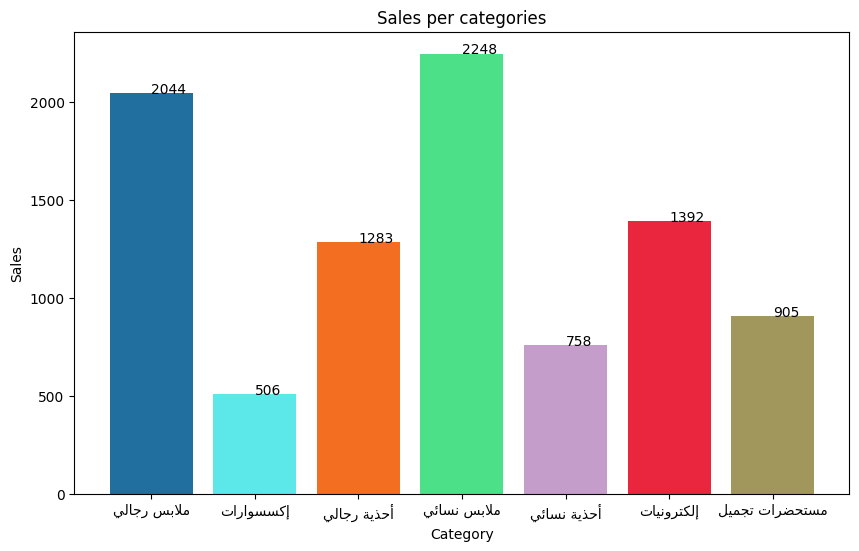

In [12]:
show_costumers_countries_bar()